# Streaming Weather Data Producer

This notebook represents the ingestion layer of the real-time building energy prediction system. In a production environment, weather observations would normally arrive from an external API, sensor network, or data provider. For this project, the historical `weather.csv` file is replayed into Kafka to simulate a live weather feed.

The producer sends weather events into the `weather_stream` Kafka topic. The downstream Spark Structured Streaming notebook consumes this topic, joins each weather window with building metadata, applies the saved machine learning model, and publishes energy predictions to Kafka output topics.

## 1. Runtime setup

The notebook starts by loading the required Python libraries for local file handling, data validation, Kafka administration, and message production. Keeping these imports in one place makes the producer easier to run in a clean environment and simpler to debug when dependency issues occur.

In [67]:
# ==========================================
# 1. Runtime Setup
# ==========================================

import json
import math
import socket
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from kafka import KafkaProducer
from kafka.admin import KafkaAdminClient, NewTopic
from kafka.errors import TopicAlreadyExistsError

from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Project and Kafka configuration

The producer is designed to run from either the project root or the `notebooks/` folder. The configuration below resolves the project directory, locates `weather.csv`, sets the Kafka broker, and defines the input topic used by the streaming prediction pipeline.

`RUN_PRODUCER` is set to `False` by default to prevent accidental message production during a full notebook run. It should be changed to `True` only after the Spark streaming prediction notebook is already active.

In [95]:
# ==========================================
# 2. Project and Kafka Configuration
# ==========================================

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
SCREENSHOT_DIR = OUTPUT_DIR / "screenshots"

WEATHER_PATH = DATA_DIR / "weather.csv"

# Use localhost:9092 when running this notebook from Mac/Anaconda/VS Code.
# Use kafka:9092 only when running from inside a Docker container on the same Docker network.
KAFKA_BROKER = "localhost:9092"
WEATHER_TOPIC = "weather_stream"

# Producer controls
BATCH_SIZE = 100
MAX_BATCHES = 20
SLEEP_SECONDS = 1
RUN_PRODUCER = True

SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Weather path:", WEATHER_PATH)
print("Kafka broker:", KAFKA_BROKER)
print("Kafka topic:", WEATHER_TOPIC)
print("Batch size:", BATCH_SIZE)
print("Max batches:", MAX_BATCHES)
print("Sleep seconds:", SLEEP_SECONDS)
print("Run producer:", RUN_PRODUCER)

if not WEATHER_PATH.exists():
    raise FileNotFoundError(f"Missing weather data file: {WEATHER_PATH}")

print("Configuration completed successfully.")

Project root: /Users/harshithreddy/building-energy-prediction-streaming
Weather path: /Users/harshithreddy/building-energy-prediction-streaming/data/weather.csv
Kafka broker: localhost:9092
Kafka topic: weather_stream
Batch size: 100
Max batches: 20
Sleep seconds: 1
Run producer: True
Configuration completed successfully.


## 3. Kafka connectivity and topic setup

Before sending data, the notebook checks whether the Kafka broker is reachable and ensures that the `weather_stream` topic exists. This avoids silent failures later in the pipeline and confirms that the producer can communicate with Kafka before any weather records are published.

In [73]:
# ==========================================
# 3. Kafka Connectivity and Topic Setup
# ==========================================

def check_kafka_connection(broker=KAFKA_BROKER, timeout=5):
    """Check whether the Kafka broker is reachable from this notebook."""

    host, port = broker.split(":")
    port = int(port)

    try:
        with socket.create_connection((host, port), timeout=timeout):
            print(f"Kafka broker is reachable: {broker}")
            return True
    except Exception as exc:
        raise ConnectionError(
            f"Kafka broker is not reachable at {broker}. "
            "Start Docker, Zookeeper and Kafka, then rerun this cell."
        ) from exc


def create_kafka_topic(topic_name=WEATHER_TOPIC, broker=KAFKA_BROKER):
    """Create the Kafka input topic if it does not already exist."""

    admin_client = None

    try:
        admin_client = KafkaAdminClient(
            bootstrap_servers=[broker],
            client_id="weather_producer_admin",
            request_timeout_ms=10000
        )

        existing_topics = admin_client.list_topics()

        if topic_name in existing_topics:
            print(f"Kafka topic already exists: {topic_name}")
        else:
            topic = NewTopic(
                name=topic_name,
                num_partitions=1,
                replication_factor=1
            )
            admin_client.create_topics(
                new_topics=[topic],
                validate_only=False
            )
            print(f"Kafka topic created: {topic_name}")

    except TopicAlreadyExistsError:
        print(f"Kafka topic already exists: {topic_name}")

    finally:
        if admin_client is not None:
            admin_client.close()


check_kafka_connection()
create_kafka_topic()

Kafka broker is reachable: localhost:9092
Kafka topic already exists: weather_stream


## 4. Load and validate weather data

The producer replays weather observations as streaming events, so the source file must contain the columns expected by the prediction pipeline. This step standardises column names, validates required fields, sorts records by timestamp, and keeps only the fields needed for downstream feature engineering.

The timestamp order is important because the streaming model aggregates weather observations into 6-hour windows before generating predictions.

In [78]:
# ==========================================
# 4. Load and Validate Weather Data
# ==========================================

weather_data = pd.read_csv(WEATHER_PATH)

# Standardise column names for consistent downstream processing
weather_data.columns = [
    col.strip().lower().replace(" ", "_").replace("-", "_")
    for col in weather_data.columns
]

required_columns = [
    "site_id",
    "timestamp",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed"
]

missing_columns = [
    col for col in required_columns
    if col not in weather_data.columns
]

if missing_columns:
    raise ValueError(f"weather.csv is missing required columns: {missing_columns}")

weather_data = weather_data[required_columns].copy()
weather_data["timestamp"] = pd.to_datetime(weather_data["timestamp"], errors="coerce")
weather_data = weather_data.dropna(subset=["site_id", "timestamp"])
weather_data["site_id"] = weather_data["site_id"].astype(int)

weather_data = (
    weather_data
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Weather data loaded successfully.")
print("Rows:", len(weather_data))
print("Columns:", list(weather_data.columns))
print("Timestamp range:", weather_data["timestamp"].min(), "to", weather_data["timestamp"].max())
print("Distinct sites:", weather_data["site_id"].nunique())

print("Sample records:")
display(weather_data.head(5))

Weather data loaded successfully.
Rows: 139773
Columns: ['site_id', 'timestamp', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'sea_level_pressure', 'wind_direction', 'wind_speed']
Timestamp range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00
Distinct sites: 16
Sample records:


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,sea_level_pressure,wind_direction,wind_speed
0,12,2022-01-01,1.9,4.0,-1.2,1016.2,200.0,5.0
1,11,2022-01-01,-1.8,NaN,-3.2,1016.0,280.0,1.5
2,8,2022-01-01,25.0,6.0,20.0,1019.7,0.0,0.0
3,13,2022-01-01,-8.3,8.0,-12.2,1023.3,250.0,4.1
4,3,2022-01-01,10.0,8.0,2.2,1021.1,350.0,4.1


## 5. Weather data quality review

A short data review is included before producing messages to Kafka. This verifies that the stream will contain records across multiple sites and time periods, and gives a quick visual check of temperature patterns that will later be used by the prediction model.

These charts are not part of the real-time pipeline itself. They are included to document the input data being replayed by the producer.

Weather records by site:


,site_id,record_count
0,0,8784
1,1,8763
2,2,8783
3,3,8780
4,4,8783
5,5,8755
6,6,8782
7,7,8614
8,8,8784
9,9,8780


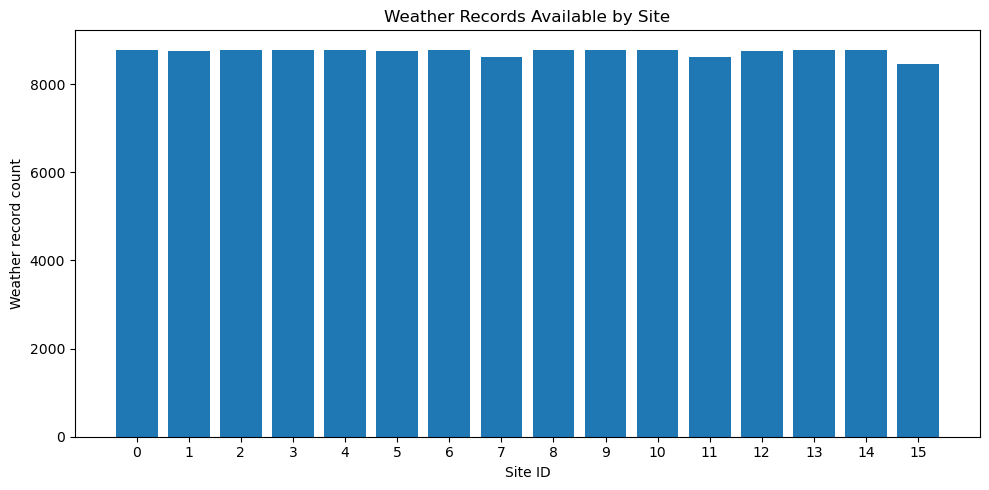

Saved plot: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/producer_weather_records_by_site.png


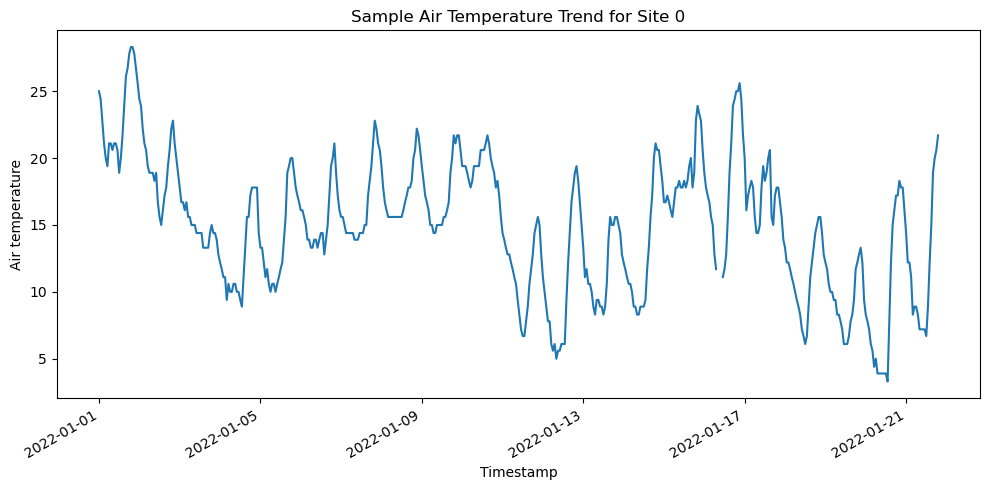

Saved plot: /Users/harshithreddy/building-energy-prediction-streaming/outputs/screenshots/producer_sample_temperature_trend.png


In [81]:
# ==========================================
# 5. Weather Data Quality Review
# ==========================================

site_counts = (
    weather_data
    .groupby("site_id")
    .size()
    .reset_index(name="record_count")
    .sort_values("site_id")
)

print("Weather records by site:")
display(site_counts)

plt.figure(figsize=(10, 5))
plt.bar(site_counts["site_id"].astype(str), site_counts["record_count"])
plt.xlabel("Site ID")
plt.ylabel("Weather record count")
plt.title("Weather Records Available by Site")
plt.tight_layout()
site_plot_path = SCREENSHOT_DIR / "producer_weather_records_by_site.png"
plt.savefig(site_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved plot:", site_plot_path)

sample_site = int(weather_data["site_id"].min())
sample_temperature = (
    weather_data[weather_data["site_id"] == sample_site]
    .head(500)
    .copy()
)

plt.figure(figsize=(10, 5))
plt.plot(sample_temperature["timestamp"], sample_temperature["air_temperature"])
plt.xlabel("Timestamp")
plt.ylabel("Air temperature")
plt.title(f"Sample Air Temperature Trend for Site {sample_site}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
temp_plot_path = SCREENSHOT_DIR / "producer_sample_temperature_trend.png"
plt.savefig(temp_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved plot:", temp_plot_path)

## 6. Prepare JSON records for Kafka

Kafka messages are sent as JSON so that the Spark streaming job can parse them using a fixed schema. Pandas timestamps, missing values and numeric types are converted into JSON-safe Python values before publishing.

Each message uses `site_id` as the key. This keeps weather records from the same site consistently identifiable when they move through the streaming pipeline.

In [84]:
# ==========================================
# 6. Prepare JSON-Safe Weather Records
# ==========================================

def make_json_safe(value):
    """Convert pandas/numpy values into JSON-safe Python values."""

    if pd.isna(value):
        return None

    if isinstance(value, pd.Timestamp):
        return value.strftime("%Y-%m-%d %H:%M:%S")

    if hasattr(value, "item"):
        return value.item()

    return value


def row_to_weather_record(row):
    """Convert one pandas row into a weather-event dictionary."""

    return {
        column: make_json_safe(row[column])
        for column in required_columns
    }

sample_record = row_to_weather_record(weather_data.iloc[0])

print("Sample JSON-ready weather record:")
print(json.dumps(sample_record, indent=4))

Sample JSON-ready weather record:
{
    "site_id": 12,
    "timestamp": "2022-01-01 00:00:00",
    "air_temperature": 1.9,
    "cloud_coverage": 4.0,
    "dew_temperature": -1.2,
    "sea_level_pressure": 1016.2,
    "wind_direction": 200.0,
    "wind_speed": 5.0
}


## 7. Kafka producer definition

The Kafka producer serialises each weather record as UTF-8 encoded JSON and publishes it to `weather_stream`. The function below sends data in controlled batches rather than all at once. This creates a realistic stream for the Spark prediction notebook and makes it easier to observe micro-batch processing in real time.

In [87]:
# ==========================================
# 7. Define Kafka Producer
# ==========================================

def create_producer(broker=KAFKA_BROKER):
    """Create a Kafka producer for JSON weather messages."""

    return KafkaProducer(
        bootstrap_servers=[broker],
        key_serializer=lambda key: str(key).encode("utf-8"),
        value_serializer=lambda value: json.dumps(value).encode("utf-8"),
        retries=3,
        linger_ms=100
    )


print("Kafka producer factory created.")

Kafka producer factory created.


## 8. Weather stream publishing logic

The producer publishes weather records in chronological order. Each batch flushes before the next batch begins so that the downstream Spark job can process records in visible micro-batches. The batch size, maximum number of batches and delay between batches can be adjusted in the configuration section.

In [97]:
# ==========================================
# 8. Define Weather Stream Publishing Function
# ==========================================

def produce_weather_data(max_batches=None, batch_size=None, sleep_seconds=None):
    """Publish weather records to Kafka in fixed-size batches."""

    if max_batches is None:
        max_batches = MAX_BATCHES

    if batch_size is None:
        batch_size = BATCH_SIZE

    if sleep_seconds is None:
        sleep_seconds = SLEEP_SECONDS

    producer = create_producer()

    total_rows = len(weather_data)
    total_sent = 0

    print("Starting weather data producer...")
    print("Topic:", WEATHER_TOPIC)
    print("Total available records:", total_rows)
    print("Batch size:", batch_size)
    print("Maximum batches:", max_batches)

    try:
        for batch_number in range(max_batches):
            start_idx = batch_number * batch_size
            end_idx = min(start_idx + batch_size, total_rows)

            if start_idx >= total_rows:
                print("No more weather records to send.")
                break

            batch_df = weather_data.iloc[start_idx:end_idx]

            for _, row in batch_df.iterrows():
                record = row_to_weather_record(row)
                message_key = record.get("site_id", "unknown")

                producer.send(
                    WEATHER_TOPIC,
                    key=message_key,
                    value=record
                )

                total_sent += 1

            producer.flush()

            print(
                f"Batch {batch_number + 1}/{max_batches} sent "
                f"({len(batch_df)} records). Total sent: {total_sent}"
            )

            time.sleep(sleep_seconds)

    finally:
        producer.flush()
        producer.close()
        print("Weather producer stopped.")
        print("Total records sent:", total_sent)

## 9. Run the producer

Run this cell only after the Spark streaming prediction notebook has started and is waiting for records from `weather_stream`. Keeping the producer controlled prevents data from being sent before the prediction stream is ready.

For a full pipeline run, set `RUN_PRODUCER = True` in the configuration cell, rerun that cell, and then run this cell.

In [100]:
# ==========================================
# 9. Run Weather Producer
# ==========================================

if RUN_PRODUCER:
    produce_weather_data()
else:
    print("Producer is not running.")
    print("Set RUN_PRODUCER = True only after spark_streaming_prediction.ipynb is active.")

/var/folders/b1/k55jnhtj1sng1ghwn0plswsw0000gn/T/ipykernel_3345/3014279374.py:17: DeprecationWarning: key_serializer does not implement kafka.serializer.Serializer
  producer = create_producer()
/var/folders/b1/k55jnhtj1sng1ghwn0plswsw0000gn/T/ipykernel_3345/3014279374.py:17: DeprecationWarning: value_serializer does not implement kafka.serializer.Serializer
  producer = create_producer()


Starting weather data producer...
Topic: weather_stream
Total available records: 139773
Batch size: 100
Maximum batches: 20
Batch 1/20 sent (100 records). Total sent: 100
Batch 2/20 sent (100 records). Total sent: 200
Batch 3/20 sent (100 records). Total sent: 300
Batch 4/20 sent (100 records). Total sent: 400
Batch 5/20 sent (100 records). Total sent: 500
Batch 6/20 sent (100 records). Total sent: 600
Batch 7/20 sent (100 records). Total sent: 700
Batch 8/20 sent (100 records). Total sent: 800
Batch 9/20 sent (100 records). Total sent: 900
Batch 10/20 sent (100 records). Total sent: 1000
Batch 11/20 sent (100 records). Total sent: 1100
Batch 12/20 sent (100 records). Total sent: 1200
Batch 13/20 sent (100 records). Total sent: 1300
Batch 14/20 sent (100 records). Total sent: 1400
Batch 15/20 sent (100 records). Total sent: 1500
Batch 16/20 sent (100 records). Total sent: 1600
Batch 17/20 sent (100 records). Total sent: 1700
Batch 18/20 sent (100 records). Total sent: 1800
Batch 19/20 

## 10. Producer completion check

After the producer finishes, the Spark streaming prediction notebook should show that new data was processed. The next stage is the consumer visualisation notebook, which reads the prediction topics and produces charts for the final project output.

In [ ]:
# ==========================================
# 10. Producer Completion Check
# ==========================================

print("Producer notebook completed.")
print("Input topic used by Spark streaming prediction:", WEATHER_TOPIC)
print("Kafka broker:", KAFKA_BROKER)
print("Run status:", "Messages were produced" if RUN_PRODUCER else "Producer was not started")